# CAB420, DCNNs, Additional Example 10: Gradient Descent Examples
Author: Dr Simon Denman (s.denman@qut.edu.au)

## Overview

This example looks at a couple of simple gradient descent examples, and attempts to explain how gradient descent works, and what momentum does. Gradient descent and momentum are key parts of how deep networks are trained, and while the examples here are not going to look at these on the same scale as they are used by deep networks (i.e. tens of thousands of parameters and more), the concepts we look at here carry across directly. 

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

### A Quick Reminder about Gradients and Derivatives

This should all be familar from maths class back in the day (and if it is just skip over it), but all the same let's quickly recap as gradients are pretty important for gradient desent (who would have guessed?).

We'll define a simple function:

$y = x^2 + 1$

The gradient of this function, at some given point, is simply the rate of change of that function at that point. The gradient of our simple function is given by the following:

$\frac{dy}{dx} = 2x$

This is the derivative of $y$ with respect to $x$, which means it's a function that describes how $y$ changes in response to changes in $x$ (or in other words, it describes the gradient of the original function). Let's plot these now. 

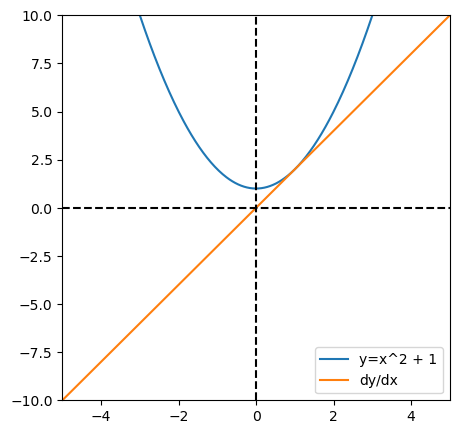

In [2]:
# our funtion
y = lambda x: x**2 + 1
# the derivative of our function
dy_dx = lambda x: 2*x

fig = plt.figure(figsize=(5, 5))
x = np.linspace(-5, 5, 400)

# Plot the functions
plt.plot(x, y(x), label='y=x^2 + 1')
plt.plot(x, dy_dx(x), label='dy/dx')

# Axes limits
plt.xlim([-5, 5])
plt.ylim([-10, 10])
plt.axvline(0, color='black', linestyle='--')
plt.axhline(0, color='black', linestyle='--')

plt.legend()

# Show the result
plt.show()

Let's quickly consider what's happening in a few different regions of this plot:
* Consider values of $x < -2$, we see here that our function $y$ is quite steep, and sloping downward (i.e. for $x < -2$, a small increase in $x$ leads to a substantial decrease in $y$). In this region we see that $\frac{dy}{dx}$ has larger negative values.
* If we now look at $x > 2$, $y$ is again quite steep but it's now heading up (i.e. a small increase in $x$ leads to a substantial increase in $y$). For this region, $\frac{dy}{dx}$ has larger positive values.
* Now consider values near $x = 0$. In this region $\frac{dy}{dx}$ is also close to 0. At $x = 0$ where $y$ reaches the bottom of the parabola we have a $\frac{dy}{dx} = 0$.

To summarise the above, when $y$ changes fast, we have large magnitudes in $\frac{dy}{dx}$; when $y$ is changing slowly, values in $\frac{dy}{dx}$ are smaller; and when $y$ is not changing $\frac{dy}{dx}$ is 0.

### So how do we get to gradient descent from this then?

Now pretend that $y$ is a loss function, like the sort of thing we'd try to minimise when fitting a model. We want to make our loss small, so that minimum value that we reach when $x=0$ is where we'd like to end up as that makes our loss as small as possible. Conveniently we find that value at the point where $\frac{dy}{dx} = 0$. When we are a long way from that point, we have larger values of $\frac{dy}{dx}$, and when we are nice and close we have smaller values of $\frac{dy}{dx}$. This is pretty much the idea behind gradient descent, that we can look at the gradient of thing we're trying to optimise, see what direction that is pointing, and a move in that direction (usually just a little bit) - and if we keep doing that we'll end up at the minimum.

A good way to think of this is rolling a ball down a hill. If you imagine having a marble that you roll down the shape defined by $y$, it will come to rest at that minima - and because $y$ is a convex function no matter where you start that ball rolling from, it will come to rest at tha minima (sadly not all functions that we try to optimise are convex).

## Example 1: Simple Gradient Descent

### Preliminaries

Gradient descent time now. Let's start by formalising what gradient descent is going to do. We're going to start with an estimate of our parameters. We'll evaluate our loss for those estimated parameters, and compute the gradient of that loss. We'll then adjust our parameters a little bit to move in a direction that will reduce that loss. We'll do that over and over again, until either we've reached a fixed number of epochs, or until performance has converged.

The movement of a single parameters is governed by the following equation:

$a_{n+1} = a_n - \eta \frac{dy}{da}$

Here, $a_n$ is the value of our parameter $a$ at timestep $n$, $\frac{dy}{da}$ is the derivative of our loss with respect to that parameter, and $\eta$ is the learning rate. $\eta$ controls how fast parameter adapts. Intuitively, you may think a large $\eta$ makes sense as it will allow the parameter to adjust fast and get to the optimum quickly, but in practice if you make this value too big updates become unstable, and model training can fail. Typical values of $\eta$ will vary from $0.01$ to $0.0001$, but depend on the situation and the algorithm used.  

### Our Problem

Our problem here is linear regression. Do we need gradient descent to solve this? No. Will we use it anyway? Yep (all in the name of education). Before we get into it, let's explore how we use gradient descent here. We're going to start with uni-variate linear regression, i.e:

$\hat{y} = \beta_1 x + \beta_0$

So, we have two unknows, $\beta_0$ and $\beta_1$. Recall that the function that we're optimising for linear regression is the mean squared error between the true values and the predicted values:

$MSE = \frac{1}{N}\sum_{i=1}^{N}(y - \hat{y})^2$

This what we need to minimise, and we can minimise this by finding values of $\beta_0$ and $\beta_1$ that minimise the gradient of the loss function. To find those gradients we need some partial derivatives. If we compute the partial derivatives of our loss, with respect to our two unknows, we get:

$\frac{dy}{d\beta_0} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y})$

$\frac{dy}{d\beta_1} = -\frac{2}{n}\sum_{i=1}^{n}x_{i}(y_i - \hat{y})$

So what we're going to do is:
* start with an estimate (guess) at what $\beta_0$ and $\beta_1$ are
* We'll then use those estimates to make some predictions and compute the gradients, $\frac{dy}{d\beta_0}$ and $\frac{dy}{d\beta_1}$
* We'll update our estimates of $\beta_0$ and $\beta_1$
* The then the above will repeat

To do this, I'm going to use the sumpy package which is a package for symbolic maths, and can do nice things like compute gradients of functions.

#### A Quick Aside

It may seem odd that we have equations with $x$ and $y$ in them, and yet the unknowns that we're solving for a $\beta_0$ and $\beta_1$. Here we have a supervised learning problem, and we're trying to fit a model to our data. Being supervised learning, we have our $x$ values and their corresponding $y$'s; hence the unknowns really are the model parameters.d

In [3]:
import sympy as sp

# Toy regression dataset
X = np.array([0., 1., 2., 3.])
Y = np.array([1., 3., 5., 7.])   # True model is y = 2x + 1

# Symbols
beta0, beta1 = sp.symbols('beta0 beta1')
x, y = sp.symbols('x y')  # one sample (we'll sum later)

# Model: ŷ = beta1*x + beta0
y_hat = beta1*x + beta0

# mean squared error for one sample
mse = (y - y_hat)**2

# derivatives of loss with respect to betas
dMSE_dbeta0_single = sp.diff(mse, beta0)
dMSE_dbeta1_single = sp.diff(mse, beta1)

# Create lambdified derivatives for fast computation
dy_dbeta0 = sp.lambdify((beta0, beta1, x, y), dMSE_dbeta0_single, 'numpy')
dy_dbeta1 = sp.lambdify((beta0, beta1, x, y), dMSE_dbeta1_single, 'numpy')
yhat_func = sp.lambdify((beta0, beta1, x), y_hat, 'numpy')

# function to wrap it all up
# X: our data
# Y: ground truth (y)
# init_b0: initial value for beta_0, default of 0
# init_b1: initial value for beta_0, default of 0
# eta: learning rate, default of 0.001
# verbose: whether to print stuff, false by default
def ex1_grad_descent(X, Y, init_b0 = 0, init_b1 = 0, eta = 0.001, verbose=False):

    # Initialise parameters
    b0 = [init_b0]
    b1 = [init_b1]
    
    for step in range(1, 10000):
        # Compute predictions
        Yhat = yhat_func(b0[step - 1], b0[step - 1], X)
    
        # Compute gradients (mean of symbolic single-sample gradients)
        grad_b0 = np.mean(dy_dbeta0(b0[step - 1], b1[step - 1], X, Y))
        grad_b1 = np.mean(dy_dbeta1(b0[step - 1], b1[step - 1], X, Y))
    
        # Gradient descent update
        b0.append(b0[step - 1] - eta * grad_b0)
        b1.append(b1[step - 1] - eta * grad_b1)
    
        # optional debug code
        if verbose & (step % 100 == 0):
            mse = np.mean((Y - Yhat)**2)
            print(f"step={step:3d}, b0={b0[step]:.4f}, b1={b1[step]:.4f}, MSE={mse:.4f}")

        # test convergence
        if abs(b1[step] - b1[step-1]) < 1e-8 and abs(b0[step] - b0[step-1]) < 1e-8:
            # print if we've stopped due to convergence
            if verbose:
                print(f"Converged after {step} iterations") 
            break
            
    if verbose:
        print("\nFinal parameters:")
        print("b0 =", b0[-1])
        print("b1 =", b1[-1])

    return b0, b1

def plot_traces(b0_trace, b1_trace):
    fig = plt.figure(figsize=[6, 6])
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(b0_trace, label="b0 (final value %1.3f)" % b0_trace[-1])
    ax.plot(b1_trace, label="b1 (final value %1.3f)" % b1_trace[-1])
    ax.legend()
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Value")
    ax.set_title("Gradient Descent Parameter Trace")

First up, let's just see how the model goes with a nice slow learning rate. You can see that our values of $\beta$ start at 0 (the initial values) and fairly quickly shift towards the true values, at which point the rate of change slows and the gradually converge to those true values. After 10,000 iterations (which is the maximum number of iterations we've given our gradient decent) the model hasn't quite converged, but it's very close.

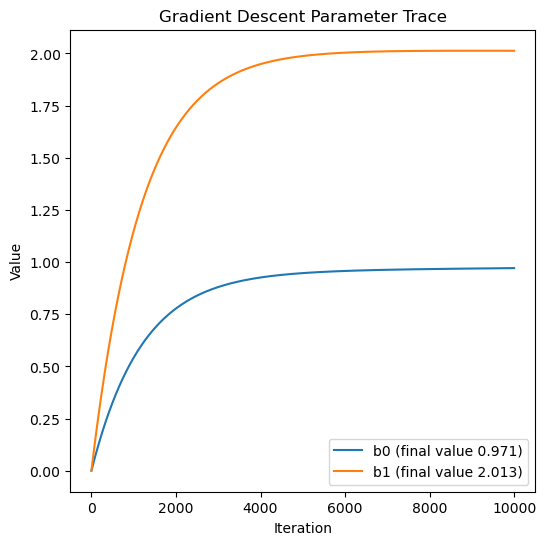

In [4]:
b0_trace, b1_trace = ex1_grad_descent(X, Y, 0, 0, 0.0001, False)
plot_traces(b0_trace, b1_trace)

Now we'll ramp up the learning rate. We can see that parameters increase much faster, and even overshoot the true values by a small amount in the case of $\beta_1$, before settling down. Here with the faster learning rate, we converge on the exact values in just over 200 steps.

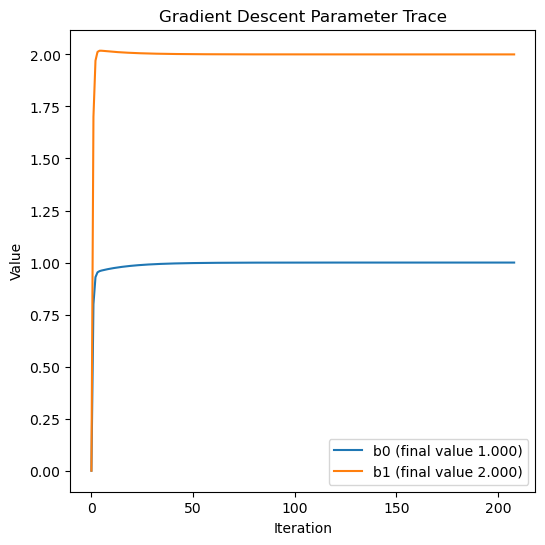

In [5]:
b0_trace, b1_trace = ex1_grad_descent(X, Y, 0, 0, 0.1, False)
plot_traces(b0_trace, b1_trace)

Now let's make the initialisation a bit weirder. We'll start with values well away from what they should be, and we see that gradient descent fairly quickly starts to pull these in the right direction (though $\beta_0$ goes the wrong way for a bit) and again we end up where we should.

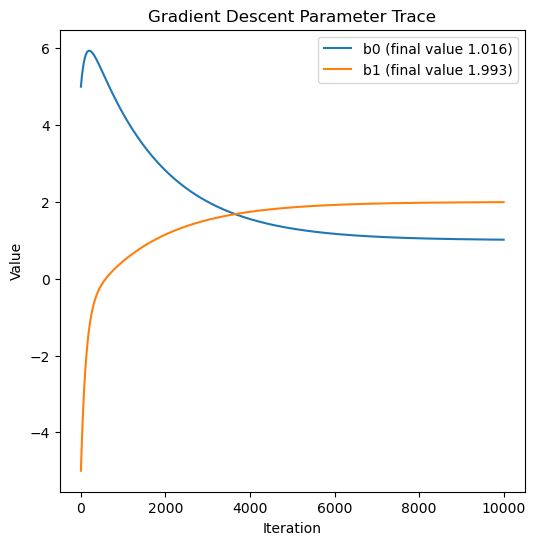

In [6]:
b0_trace, b1_trace = ex1_grad_descent(X, Y, 5, -5, 0.001, False)
plot_traces(b0_trace, b1_trace)

## Example 2: Gradient Descent with Momentum

Not all cost functions will have one negative slope and one positive slope, with a nice big minima in between. As a simple example, consider the following quartic and it's derivative:

$y = x^4 - 2x^3 - 4x^2 + 2x + 3$

$\frac{dy}{dx} = 4x^3 - 6x^2 - 8x + 2$

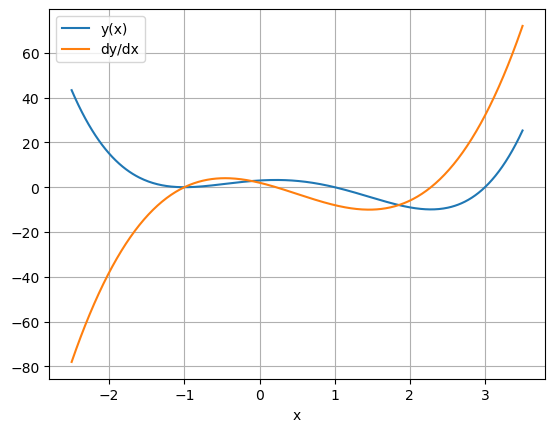

In [7]:
# Symbols
beta0, beta1, beta2, beta3, beta4 = sp.symbols('beta0 beta1 beta2 beta3 beta4')
x, y = sp.symbols('x y')

# True model is = x**4 - 2*x**3 - 4*x**2 + 2*x + 3
y_true = x**4 - 2*x**3 - 4*x**2 + 2*x + 3
dy_dx = sp.diff(y_true, x)

y_func = sp.lambdify((x), y_true, 'numpy')
dydx_func = sp.lambdify((x), dy_dx, 'numpy')
xs = np.linspace(-2.5, 3.5, 400)

# Plot
plt.plot(xs, y_func(xs), label="y(x)")
plt.plot(xs, dydx_func(xs), label="dy/dx")
plt.xlabel("x")
plt.grid(True)
plt.legend()
plt.show()

In the above we can see that our derivative has two minima. The local minima on the left at about $-1$ is not as good as the global minima on the right. With a simple gradient descent approach, there is a chance that we'd get stuck in the local minima, leading to a sub-optimal model. 

While this example is fairly simple with only two minima, in practice when we start to optimise more complex things (like deep nets), we can have multiple local minima - many of which may be very poor compared to the glocal minima - and gradient descent can very easily get stuck in these less good local minima. One naive way to try and avoid this is to increase the learning rate to simply try and skip over these local minima, but this has it's own issues - namely that it can introduce instability and lead to training failing. Another approach that we can introduce is momentum.

Momemtum simply involves smoothing our parameters updates over time. Instead of moving only in the direction of the current gradient, momentum keeps a moving average that combines past updates. This helps the optimiser maintain movement in consistent directions and dampen oscillations in noisy or steep regions, allowing faster and more stable convergence. Going back to our simple idea of rolling balls down hills, we can simply think of our ball building up speed as it rolls down a hill, and then this speed to used to keep carrying our ball forward out of a local minima as it continues towards the global minima.

As the above suggests, adding mommentum means that we need to change our update equations. We now need to keep track of the average of our gradients, and use this average to make our updates, which are can represent as follows:

$\mu_a = \gamma\mu_a + (1 - \gamma)\frac{dy}{da}$

$a_{n+1} = a_n - \eta\mu_a$

where $\mu_a$ is our average gradient for parameter $a$, and $\gamma$ is our smoothing factor, that controls how much smoothing (effectivley how large of a window) we are considering when updating our average gradient.

We'll now take a look at this in practice. We're going to use the quartic that we mentioned above here and treat this as a simple regression task. We'll try recover the values of $\beta$ for the following:

$\hat{y} = \beta_0 x^4 + \beta_1 x^3 + \beta_2 x^2 + \beta_3 x + \beta_4$

To add a wrinkle, we'll under constrain this problem too in that we'll only give the model 4 points - where as ideally we'd have five or more given that we have five coefficients to recover.

As per above, we'll set this up using sympy.

In [8]:
# create some data, we'll create some X values and pump those through the true function to get our Y values
X = np.array([0., 1., 2., 3.])
Y = y_func(X)

# create the version of y that we'll use to get partial derivatives, and find coefficients
y_hat = beta0*(x**4) + beta1*(x**3) + beta2*(x**2) + beta3*x + beta4

# mean squared error for one sample
mse = (y - y_hat)**2

# partial deravities
dMSE_dbeta0_single = sp.diff(mse, beta0)
dMSE_dbeta1_single = sp.diff(mse, beta1)
dMSE_dbeta2_single = sp.diff(mse, beta2)
dMSE_dbeta3_single = sp.diff(mse, beta3)
dMSE_dbeta4_single = sp.diff(mse, beta4)

# Create lambdified derivatives for fast computation
dy_dbeta0 = sp.lambdify((beta0, beta1, beta2, beta3, beta4, x, y), dMSE_dbeta0_single, 'numpy')
dy_dbeta1 = sp.lambdify((beta0, beta1, beta2, beta3, beta4, x, y), dMSE_dbeta1_single, 'numpy')
dy_dbeta2 = sp.lambdify((beta0, beta1, beta2, beta3, beta4, x, y), dMSE_dbeta2_single, 'numpy')
dy_dbeta3 = sp.lambdify((beta0, beta1, beta2, beta3, beta4, x, y), dMSE_dbeta3_single, 'numpy')
dy_dbeta4 = sp.lambdify((beta0, beta1, beta2, beta3, beta4, x, y), dMSE_dbeta4_single, 'numpy')
yhat_func = sp.lambdify((beta0, beta1, beta2, beta3, beta4, x), y_hat, 'numpy')

def ex2_grad_descent_w_momemtum(X, Y, 
                                init_b0 = 0.0, init_b1 = 0.0, init_b2 = 0.0, init_b3 = 0.0, init_b4 = 0.0, 
                                eta = 0.001, gamma = 0.9, verbose=False):

    # Initialise parameters
    b0 = [init_b0]
    b1 = [init_b1]
    b2 = [init_b2]
    b3 = [init_b3]
    b4 = [init_b4]

    # initialise average gradients
    mu_b0 = 0;
    mu_b1 = 0;
    mu_b2 = 0;
    mu_b3 = 0;
    mu_b4 = 0;
    
    for step in range(1, 100000):
        # Compute predictions
        Yhat = yhat_func(b0[step - 1], b1[step - 1], b2[step - 1], b3[step - 1], b4[step - 1], X)
    
        # Compute gradients (mean of symbolic single-sample gradients)
        grad_b0 = np.mean(dy_dbeta0(b0[step - 1], b1[step - 1], b2[step - 1], b3[step - 1], b4[step - 1], X, Y))
        grad_b1 = np.mean(dy_dbeta1(b0[step - 1], b1[step - 1], b2[step - 1], b3[step - 1], b4[step - 1], X, Y))
        grad_b2 = np.mean(dy_dbeta2(b0[step - 1], b1[step - 1], b2[step - 1], b3[step - 1], b4[step - 1], X, Y))
        grad_b3 = np.mean(dy_dbeta3(b0[step - 1], b1[step - 1], b2[step - 1], b3[step - 1], b4[step - 1], X, Y))
        grad_b4 = np.mean(dy_dbeta4(b0[step - 1], b1[step - 1], b2[step - 1], b3[step - 1], b4[step - 1], X, Y))

        # update average gradients
        mu_b0 = gamma*mu_b0 + (1-gamma)*grad_b0;
        mu_b1 = gamma*mu_b1 + (1-gamma)*grad_b1;
        mu_b2 = gamma*mu_b2 + (1-gamma)*grad_b2;
        mu_b3 = gamma*mu_b3 + (1-gamma)*grad_b3;
        mu_b4 = gamma*mu_b4 + (1-gamma)*grad_b4;
    
        # Gradient descent update, now using our average rather than the raw gradients
        b0.append(b0[step - 1] - eta * mu_b0)
        b1.append(b1[step - 1] - eta * mu_b1)
        b2.append(b2[step - 1] - eta * mu_b2)
        b3.append(b3[step - 1] - eta * mu_b3)
        b4.append(b4[step - 1] - eta * mu_b4)
    
        # Monitoring
        if verbose & (step % 10000 == 0):
            mse = np.mean((Y - Yhat)**2)
            print(f"step={step:3d}, b0={b0[step]:.4f}, b1={b1[step]:.4f}, b2={b2[step]:.4f}, b3={b3[step]:.4f}, b4={b4[step]:.4f}, MSE={mse:.4f}")

        # test convergence
        if abs(b0[step] - b0[step-1]) < 1e-8 and abs(b1[step] - b1[step-1]) < 1e-8 and abs(b2[step] - b2[step-1]) < 1e-8 and abs(b3[step] - b3[step-1]) < 1e-8 and abs(b4[step] - b4[step-1]) < 1e-8:
            # print if we've stopped due to convergence
            if verbose:
                print(f"Converged after {step} iterations") 
            break

    
    if verbose:
        print("\nFinal parameters:")
        print("b0 =", b0[-1])
        print("b1 =", b1[-1])
        print("b2 =", b2[-1])
        print("b3 =", b3[-1])
        print("b4 =", b4[-1])

    return b0, b1, b2, b3, b4

def ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace, title = ""):

    fig = plt.figure(figsize=[20, 6])
    ax = fig.add_subplot(1, 3, 1)

    ax.plot(b0_trace, label="b0 (final value %1.3f)" % b0_trace[-1])
    ax.plot(b1_trace, label="b1 (final value %1.3f)" % b1_trace[-1])
    ax.plot(b2_trace, label="b2 (final value %1.3f)" % b2_trace[-1])
    ax.plot(b3_trace, label="b3 (final value %1.3f)" % b3_trace[-1])
    ax.plot(b4_trace, label="b4 (final value %1.3f)" % b4_trace[-1])
    ax.legend()
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Value")
    ax.set_title("Gradient Descent Parameter Trace")

    ax = fig.add_subplot(1, 3, 2)

    ax.plot(b0_trace[0:100], label="b0")
    ax.plot(b1_trace[0:100], label="b1")
    ax.plot(b2_trace[0:100], label="b2")
    ax.plot(b3_trace[0:100], label="b3")
    ax.plot(b4_trace[0:100], label="b4")
    ax.legend()
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Value")
    ax.set_title("Gradient Descent Parameter Trace (first 100 values)")

    # Evaluate the function
    y_t = y_func(xs)
    y_p = yhat_func(b0_trace[-1], b1_trace[-1], b2_trace[-1], b3_trace[-1], b4_trace[-1], xs)
    
    ax = fig.add_subplot(1, 3, 3)
    # Plot
    ax.plot(xs, y_t, label="True")
    ax.plot(xs, y_p, label="Pred")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("True and Fitted Functions")
    ax.grid(True)

    fig.suptitle(title)

Let's start with momentum turned off, which we can do by setting $\gamma = 0$.

/opt/conda/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in multiply
  return beta0*x**4 + beta1*x**3 + beta2*x**2 + beta3*x + beta4
<lambdifygenerated-6>:2: RuntimeWarning: invalid value encountered in multiply
  return -2*x**4*(-beta0*x**4 - beta1*x**3 - beta2*x**2 - beta3*x - beta4 + y)
<lambdifygenerated-7>:2: RuntimeWarning: invalid value encountered in multiply
  return -2*x**3*(-beta0*x**4 - beta1*x**3 - beta2*x**2 - beta3*x - beta4 + y)
<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in multiply
  return -2*x**2*(-beta0*x**4 - beta1*x**3 - beta2*x**2 - beta3*x - beta4 + y)
<lambdifygenerated-9>:2: RuntimeWarning: invalid value encountered in multiply
  return -2*x*(-beta0*x**4 - beta1*x**3 - beta2*x**2 - beta3*x - beta4 + y)
<lambdifygenerated-10>:2: RuntimeWarning: invalid

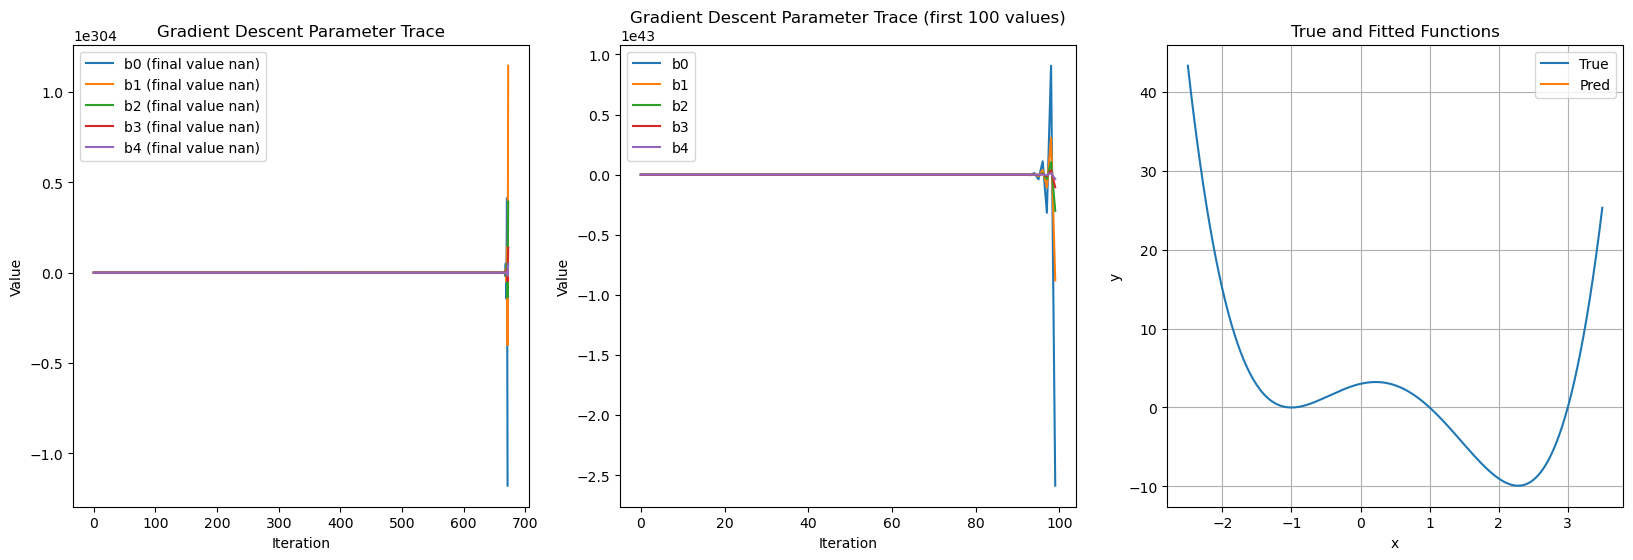

In [9]:
b0_trace, b1_trace, b2_trace, b3_trace, b4_trace = ex2_grad_descent_w_momemtum(X, Y, eta = 0.001, gamma=0.0, verbose = False)
ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace)

Things fail. Even with a fairly modest learning rate we get some numerical instability and our parameters all get quite big quite fast. The plot from the first 100 values hints at what's happening here, where the updates start ot oscillate and get increasingly large, before going to nan. We could address this by slowing the learning rate, but momentum will also help as this will smooth our updates and prevent huge updates breaking things.

Let's use a $\gamma$ that will only look at a short window of gradients.

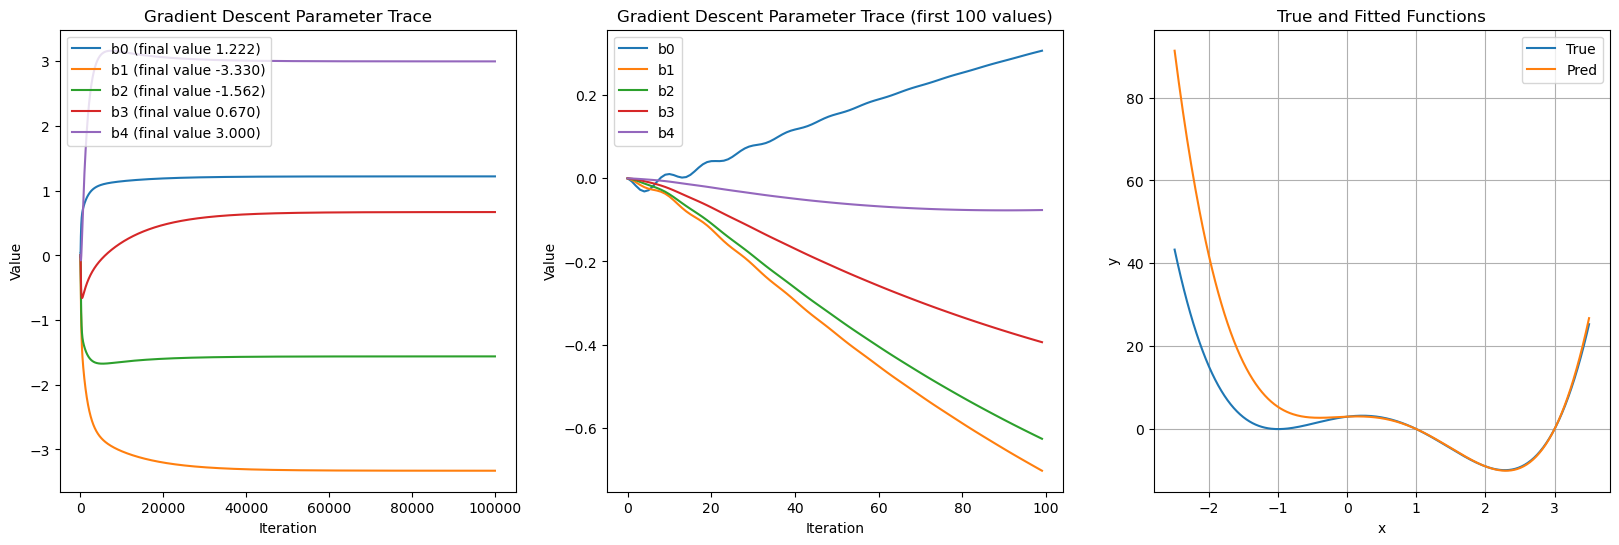

In [10]:
b0_trace, b1_trace, b2_trace, b3_trace, b4_trace = ex2_grad_descent_w_momemtum(X, Y, eta = 0.001, gamma=0.9, verbose = False)
ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace)

This is enough to avoid the instability we saw before, as we see that the process fairly quickly converges towards some good values. We get some little wobbles in the parameter traces early on, but these are kept under control by momentum and we learn a good solution. Note that we don't recover the exact curve (the problem is under-constrained), but get something pretty good (recall too that our points where at $x=0$, $x=1$, $x=2$, and $x=3$, and our curve fits pretty well in that region). 

Let's now make $\gamma$ bigger.

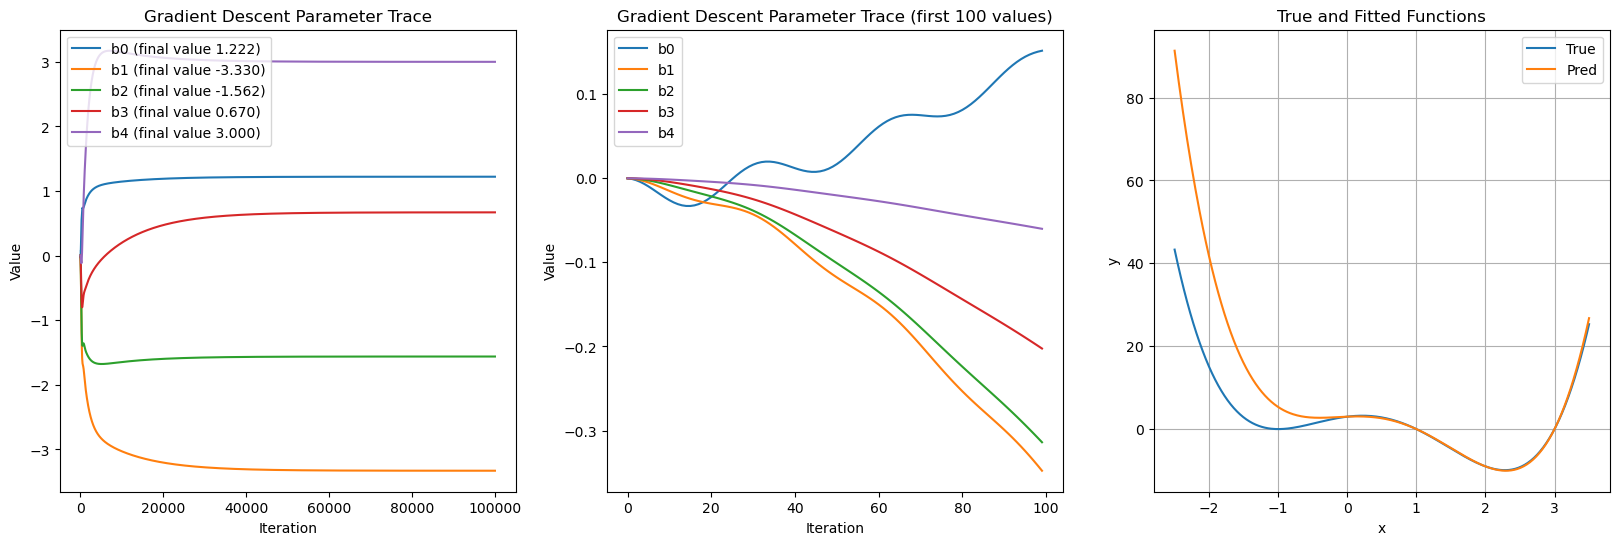

In [11]:
b0_trace, b1_trace, b2_trace, b3_trace, b4_trace = ex2_grad_descent_w_momemtum(X, Y, eta = 0.001, gamma=0.99, verbose = False)
ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace)

Now we're considering larger windows of gradient values, so those wobbles in the parameters become lower frequency, but they're bigger in magnitude as it takes longer to adapt as we're looking at a larger window. We can see this behaviour very clearly if we increase $\gamma$ again.

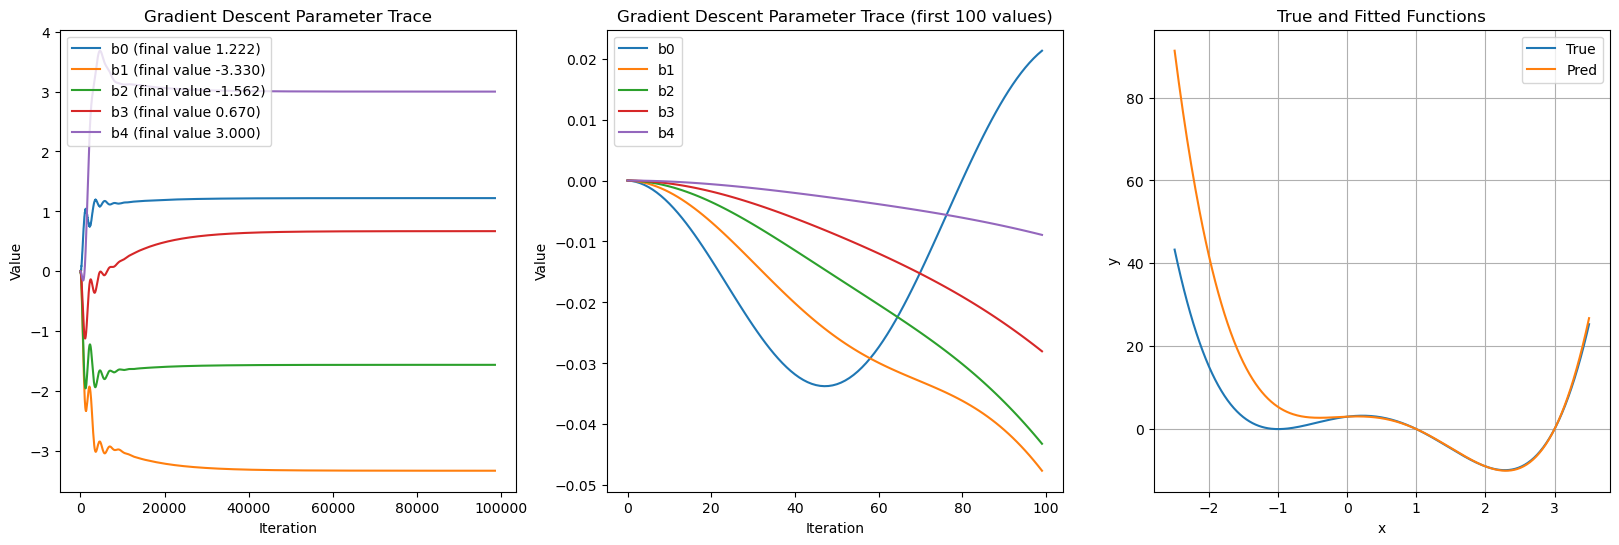

In [12]:
b0_trace, b1_trace, b2_trace, b3_trace, b4_trace = ex2_grad_descent_w_momemtum(X, Y, eta = 0.001, gamma=0.999, verbose = False)
ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace)

As we've already highlighted, with momentum you really can start to crank up the learning rate, though you will often need to dial up the momentum too to keep things stable. The two below runs show this. These converge far quicker than the above runs, though you can see the parameters swinging back and forth as the momemtum term tries to keep things smooth and prevent gradients exploding.

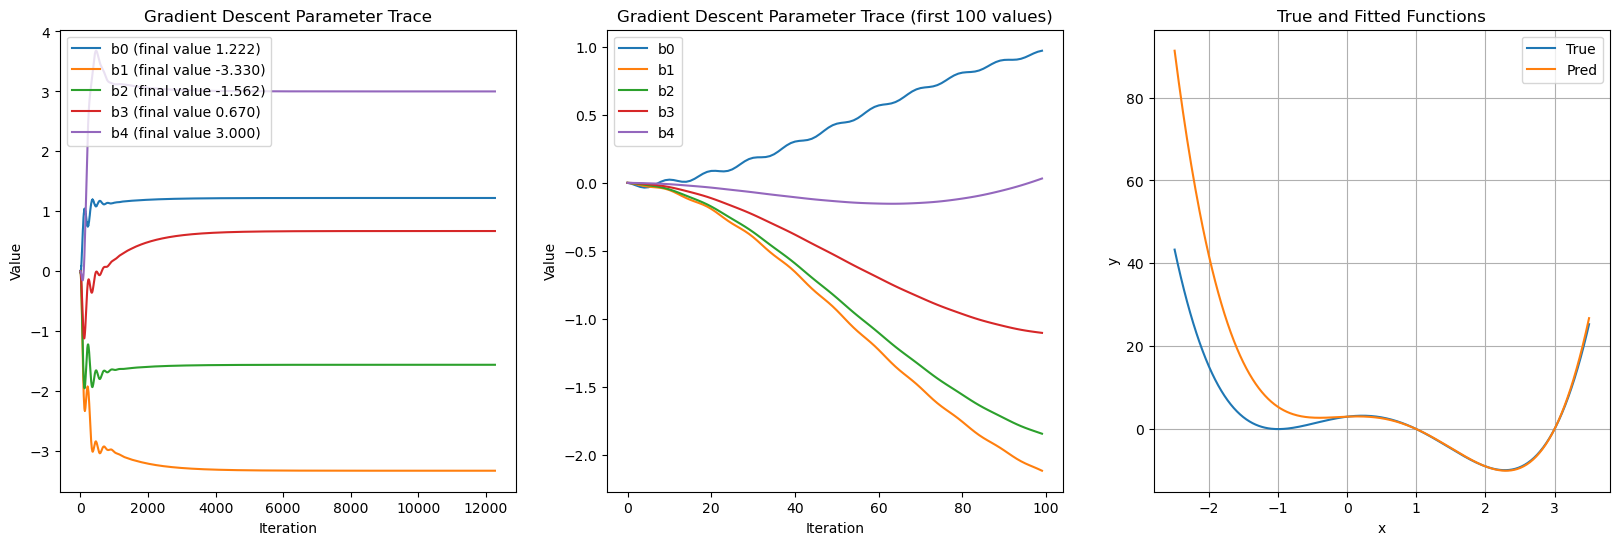

In [13]:
b0_trace, b1_trace, b2_trace, b3_trace, b4_trace = ex2_grad_descent_w_momemtum(X, Y, eta = 0.01, gamma=0.99, verbose = False)
ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace)

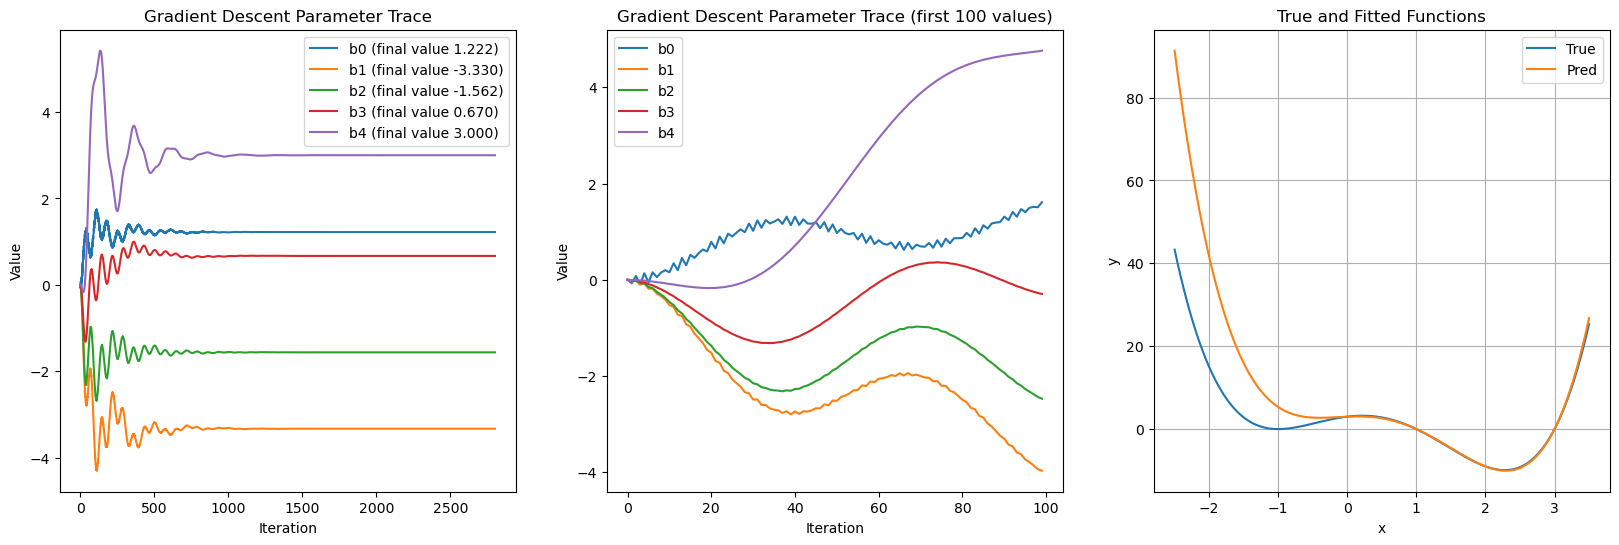

In [14]:
b0_trace, b1_trace, b2_trace, b3_trace, b4_trace = ex2_grad_descent_w_momemtum(X, Y, eta = 0.1, gamma=0.99, verbose = False)
ex2_plot_results(b0_trace, b1_trace, b2_trace, b3_trace, b4_trace)

The above too examples where we have really cranked the learning rate is not recommened - we've done that to show what momemtum does and how that can help keep large updates in check. 